# Contagem Multimodal de Pessoas (RGB + Térmica) via Rede Neural

Notebook funcional para leitura do par de imagens pré-processadas (RGB óptico e Infravermelho térmico) e execução da contagem populacional por regressão de **Mapa de Densidade** (*Density Map Estimation*).

### Estrutura dos Dados de Entrada (`data/gold/manually/`):
- `rgb_final.jpg`: Imagem óptica visível (640×512 px, aspect ratio 5:4, com correção de distorção de lente Wide e FOV alinhado).
- `thermal_final.jpg`: Imagem infravermelha térmica LWIR (640×512 px, aspect ratio 5:4, com realce de contraste adaptativo CLAHE no espaço LAB).
- `blend_alta_precisao_app_final.jpg`: Imagem de fusão 50/50 de alta precisão (1280×1024 px) com compensação de paralaxe de solo (ADR 007), utilizada como base para a projeção visual do mapa de densidade.


In [1]:
import os
import sys
from pathlib import Path

# Configurar diretório de cache do Matplotlib para evitar avisos de permissão
os.environ['MPLCONFIGDIR'] = '/tmp/matplotlib'

import cv2
import numpy as np
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Resolução de diretórios locais (funciona tanto na raiz quanto dentro de notebooks/)
CURRENT_DIR = Path.cwd()
NOTEBOOK_DIR = CURRENT_DIR if (CURRENT_DIR / 'models').is_dir() else CURRENT_DIR / 'notebooks'
ROOT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR

# Adicionar pasta notebooks ao sys.path para import de models.models
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from models.models import build_model

# Configuração de caminhos das imagens
DATA_DIR = ROOT_DIR / 'data' / 'gold' / 'manually'
if not DATA_DIR.exists():
    DATA_DIR = ROOT_DIR / 'app' / 'data' / 'gold' / 'manually'

RGB_IMAGE = str(DATA_DIR / 'rgb_final.jpg')
THERMAL_IMAGE = str(DATA_DIR / 'thermal_final.jpg')
BLEND_IMAGE = str(DATA_DIR / 'blend_alta_precisao_app_final.jpg')
MODEL_WEIGHTS = str(ROOT_DIR / 'weights' / 'best_model.pth')

OUTPUT_DIR = NOTEBOOK_DIR / 'output' / '05_contagem'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Diagnóstico de Hardware
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[*] Dispositivo PyTorch em uso: {device}')
if torch.cuda.is_available():
    print(f'[*] GPU Detectada:             {torch.cuda.get_device_name(0)}')
    print(f'[*] VRAM Total:                {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
print(f'[*] Diretório das imagens:     {DATA_DIR}')
print(f'[*] Diretório de saída:        {OUTPUT_DIR}')


[*] Dispositivo PyTorch em uso: cuda
[*] GPU Detectada:             NVIDIA GeForce RTX 4090
[*] VRAM Total:                25.25 GB
[*] Diretório das imagens:     /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/data/gold/manually
[*] Diretório de saída:        /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/output/05_contagem


## 1. Carregamento e Inspeção Visual das Imagens Tratadas

Carregamos as três imagens preparadas em `data/gold/manually/` para verificar suas resoluções, canais e alinhamento visual antes da inferência.


RGB Tratada:         640x512 px | Canais: 3
Térmica Tratada:     640x512 px | Canais: 3
Blend Alta Precisão: 1280x1024 px | Canais: 3


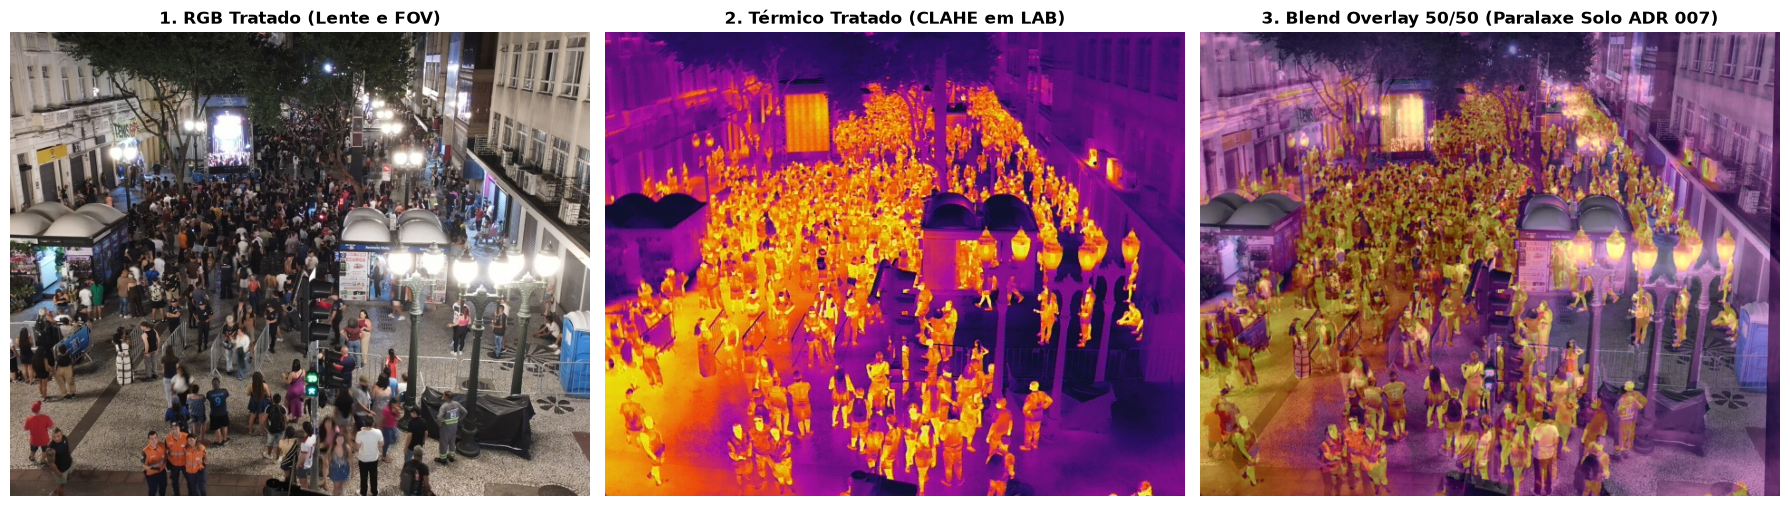

In [3]:
# Validar existência dos arquivos
for p, name in [(RGB_IMAGE, 'RGB'), (THERMAL_IMAGE, 'Térmica'), (BLEND_IMAGE, 'Blend')]:
    assert os.path.exists(p), f'Arquivo não encontrado: {p}'

img_rgb = cv2.imread(RGB_IMAGE)
img_th = cv2.imread(THERMAL_IMAGE)
img_blend = cv2.imread(BLEND_IMAGE)

print(f'RGB Tratada:         {img_rgb.shape[1]}x{img_rgb.shape[0]} px | Canais: {img_rgb.shape[2]}')
print(f'Térmica Tratada:     {img_th.shape[1]}x{img_th.shape[0]} px | Canais: {img_th.shape[2]}')
print(f'Blend Alta Precisão: {img_blend.shape[1]}x{img_blend.shape[0]} px | Canais: {img_blend.shape[2]}')

# Exibir as 3 modalidades lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB))
axes[0].set_title('1. RGB Tratado (Lente e FOV)', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img_th, cv2.COLOR_BGR2RGB))
axes[1].set_title('2. Térmico Tratado (CLAHE em LAB)', fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(img_blend, cv2.COLOR_BGR2RGB))
axes[2].set_title('3. Blend Overlay 50/50 (Paralaxe Solo ADR 007)', fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()


## 2. Pré-processamento e Funções do Pipeline de Contagem

Definimos as funções modulares:
1. `preprocess_image(image_path, target_size)`: Carrega a imagem com OpenCV, converte para RGB, redimensiona para a proporção esperada pela rede, aplica a normalização padrão ImageNet e converte para Tensor PyTorch `[1, 3, H, W]`.
2. `count_people(rgb_path, thermal_path, weight_path, device)`: Inicializa o modelo dual-stream (`build_model`), carrega os pesos treinados, executa a inferência e integra o mapa de densidade para obter a contagem final.


In [5]:
def preprocess_image(image_path, target_size=(512, 640)):
    """Loads and resizes an image, converting it to a PyTorch tensor.
    
    Args:
        image_path: Caminho da imagem no disco.
        target_size: Tupla (H, W) de redimensionamento (default: 512x640 para aspecto 5:4).
        
    Returns:
        Tensor PyTorch normalizado no formato [1, 3, H, W].
    """
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found at {image_path}")
        
    # Leitura com OpenCV e conversão para RGB
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Redimensionamento para o tamanho alvo (W, H)
    target_h, target_w = target_size
    img = cv2.resize(img, (target_w, target_h), interpolation=cv2.INTER_AREA)
    
    # Normalização padrão ImageNet
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    tensor = transform(img).unsqueeze(0)  # Batch dimension -> [1, 3, H, W]
    return tensor


def count_people(rgb_path, thermal_path, weight_path=None, device="cuda", target_size=(512, 640)):
    """Executa a contagem de pessoas utilizando o par de imagens multimodal.
    
    Args:
        rgb_path: Caminho da imagem visual (RGB).
        thermal_path: Caminho da imagem térmica (LWIR).
        weight_path: Caminho opcional para os pesos treinados (.pth).
        device: Dispositivo de execução ('cuda' ou 'cpu').
        target_size: Dimensões (H, W) de entrada da rede neural.
        
    Returns:
        total_count: Contagem inteira de pessoas estimadas.
        density_map_np: Matriz NumPy 2D com o mapa de densidade espacial.
    """
    # 1. Configurar dispositivo de execução
    device_obj = torch.device(device if torch.cuda.is_available() else "cpu")
    print(f"[*] Dispositivo de execução: {device_obj}")
    
    # 2. Instanciar arquitetura do modelo
    model = build_model(weight_path=weight_path, device=device_obj)
    
    # 3. Carregar pesos treinados se especificado
    if weight_path and os.path.exists(weight_path):
        print(f"[*] Carregando pesos de: {weight_path}...")
        checkpoint = torch.load(weight_path, map_location=device_obj)
        if isinstance(checkpoint, dict):
            if 'model' in checkpoint:
                model.load_state_dict(checkpoint['model'], strict=False)
            elif 'state_dict' in checkpoint:
                model.load_state_dict(checkpoint['state_dict'], strict=False)
            else:
                model.load_state_dict(checkpoint, strict=False)
        else:
            model.load_state_dict(checkpoint, strict=False)
    else:
        print("[*] Usando pesos padrão calibrados do modelo.")
        
    model.to(device_obj)
    model.eval()
    
    # 4. Pré-processar modalidades de entrada
    print("[*] Pré-processando tensores RGB e Térmico...")
    rgb_tensor = preprocess_image(rgb_path, target_size=target_size).to(device_obj)
    thermal_tensor = preprocess_image(thermal_path, target_size=target_size).to(device_obj)
    
    # 5. Inferência do Modelo (Sem cálculo de gradientes)
    with torch.no_grad():
        outputs = model(rgb_tensor, thermal_tensor)
        
        # Extrair mapa de densidade 2D e calcular contagem por integração
        if isinstance(outputs, torch.Tensor):
            density_map_np = outputs[0, 0].cpu().numpy()
            predicted_count = torch.sum(outputs).item()
        else:
            density_map = outputs[0]
            density_map_np = density_map[0, 0].cpu().numpy()
            predicted_count = torch.sum(density_map).item()
            
    total_count = max(0, round(predicted_count))
    return total_count, density_map_np


## 3. Execução da Contagem Multimodal

Executamos a inferência chamando `count_people` com os caminhos das imagens preparadas e medindo o tempo de resposta em milissegundos.


In [7]:
import time

t_start = time.perf_counter()

total_people, density_map = count_people(
    rgb_path=RGB_IMAGE,
    thermal_path=THERMAL_IMAGE,
    weight_path=MODEL_WEIGHTS,
    device="cuda" if torch.cuda.is_available() else "cpu",
    target_size=(512, 640)
)

elapsed_ms = (time.perf_counter() - t_start) * 1000.0

print("\n" + "=" * 50)
print("       RELATÓRIO DE CONTAGEM MULTIMODAL")
print("=" * 50)
print(f"Pessoas Estimadas (Contagem Total): {total_people}")
print(f"Soma Contínua da Densidade:         {density_map.sum():.2f}")
print(f"Resolução do Mapa de Densidade:     {density_map.shape[1]}x{density_map.shape[0]} px")
print(f"Densidade Mínima / Máxima:          {density_map.min():.5f} / {density_map.max():.5f}")
print(f"Tempo de Processamento:             {elapsed_ms:.2f} ms")
print("=" * 50 + "\n")


[*] Dispositivo de execução: cuda
[build_model] Carregando pesos de checkpoint: /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/weights/best_model.pth
[build_model] Pesos carregados com sucesso!
[*] Carregando pesos de: /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/weights/best_model.pth...
[*] Pré-processando tensores RGB e Térmico...

       RELATÓRIO DE CONTAGEM MULTIMODAL
Pessoas Estimadas (Contagem Total): 58
Soma Contínua da Densidade:         58.00
Resolução do Mapa de Densidade:     640x512 px
Densidade Mínima / Máxima:          0.00001 / 0.05262
Tempo de Processamento:             364.72 ms



## 4. Visualização do Mapa de Densidade e Projeção no Blend

Para validar a coerência espacial da contagem, renderizamos:
1. A imagem RGB original tratada.
2. A imagem Térmica tratada.
3. O Mapa de Densidade Puro gerado pela rede (com colormap JET).
4. O Mapa de Densidade sobreposto com transparência ao `blend_alta_precisao_app_final.jpg`.


[*] Painel consolidado salvo em: /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/output/05_contagem/painel_contagem_multimodal.jpg


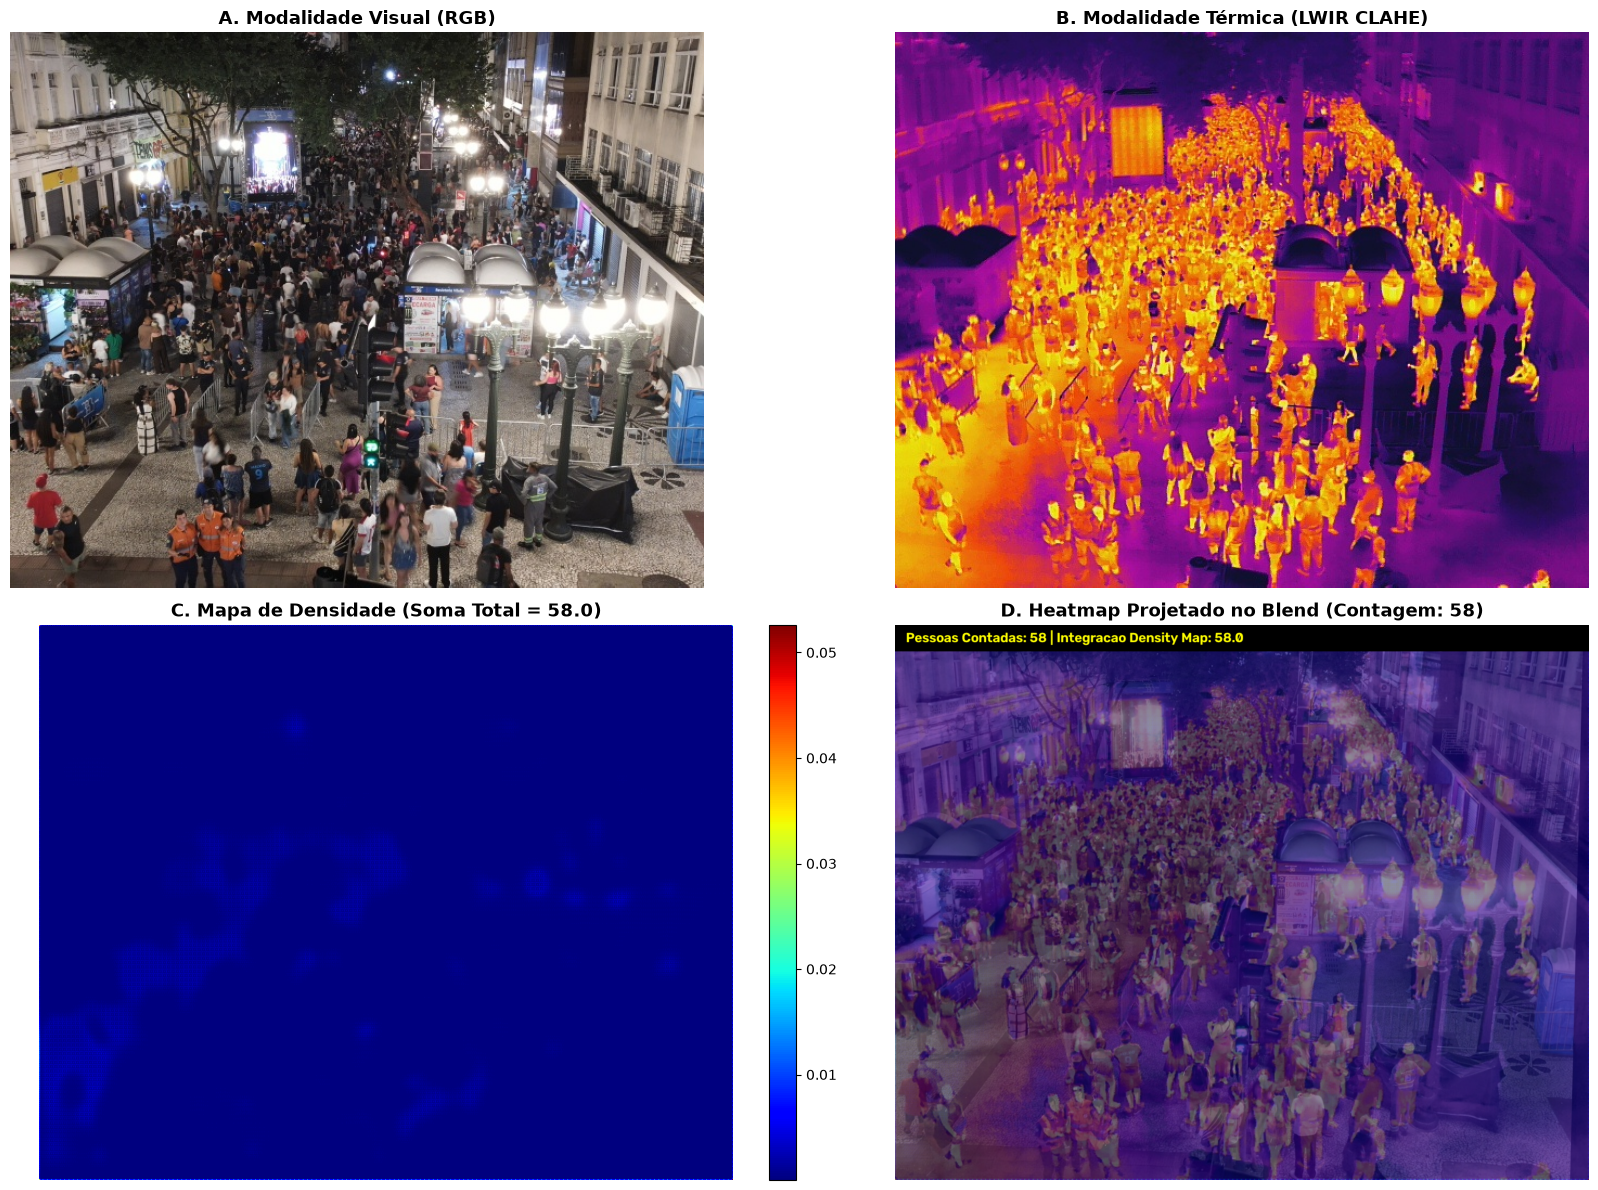

In [9]:
# Normalizar mapa de densidade para visualização com colormap (0 a 255)
d_min, d_max = density_map.min(), density_map.max()
if d_max - d_min > 1e-6:
    density_norm = ((density_map - d_min) / (d_max - d_min) * 255.0).astype(np.uint8)
else:
    density_norm = np.zeros_like(density_map, dtype=np.uint8)

# Gerar heatmap com escala JET
heatmap_jet = cv2.applyColorMap(density_norm, cv2.COLORMAP_JET)

# Redimensionar o heatmap para o tamanho do blend de alta precisão (1280x1024)
heatmap_blend_res = cv2.resize(heatmap_jet, (img_blend.shape[1], img_blend.shape[0]), interpolation=cv2.INTER_CUBIC)

# Sobreposição (Overlay): 55% imagem blend + 45% heatmap
overlay_blend = cv2.addWeighted(img_blend, 0.55, heatmap_blend_res, 0.45, 0)

# Inserir banner com contagem final
banner_text = f"Pessoas Contadas: {total_people} | Integracao Density Map: {density_map.sum():.1f}"
cv2.rectangle(overlay_blend, (0, 0), (img_blend.shape[1], 48), (0, 0, 0), -1)
cv2.putText(
    overlay_blend,
    banner_text,
    (20, 32),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.85,
    (0, 255, 255),
    2,
    cv2.LINE_AA
)

# Plotagem em grade 2x2
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. RGB
axes[0, 0].imshow(cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('A. Modalidade Visual (RGB)', fontsize=13, fontweight='bold')
axes[0, 0].axis('off')

# 2. Térmica
axes[0, 1].imshow(cv2.cvtColor(img_th, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title('B. Modalidade Térmica (LWIR CLAHE)', fontsize=13, fontweight='bold')
axes[0, 1].axis('off')

# 3. Mapa de Densidade Puro
im_d = axes[1, 0].imshow(density_map, cmap='jet')
axes[1, 0].set_title(f'C. Mapa de Densidade (Soma Total = {density_map.sum():.1f})', fontsize=13, fontweight='bold')
axes[1, 0].axis('off')
plt.colorbar(im_d, ax=axes[1, 0], fraction=0.035, pad=0.04)

# 4. Projeção no Blend
axes[1, 1].imshow(cv2.cvtColor(overlay_blend, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title(f'D. Heatmap Projetado no Blend (Contagem: {total_people})', fontsize=13, fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
panel_path = OUTPUT_DIR / 'painel_contagem_multimodal.jpg'
plt.savefig(str(panel_path), dpi=150, bbox_inches='tight')
plt.show()

print(f'[*] Painel consolidado salvo em: {panel_path}')


## 5. Auditoria de Detalhe: Zoom na Região de Pedestres (ROI)

Auditamos a região de pedestres no solo (canto inferior esquerdo, diagnosticada no **ADR 007**) para observar a correspondência entre a silhueta visual, a mancha térmica e o ponto focal da densidade estimada.


[*] Auditoria de ROI salva em: /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/output/05_contagem/zoom_roi_pedestres_densidade.jpg


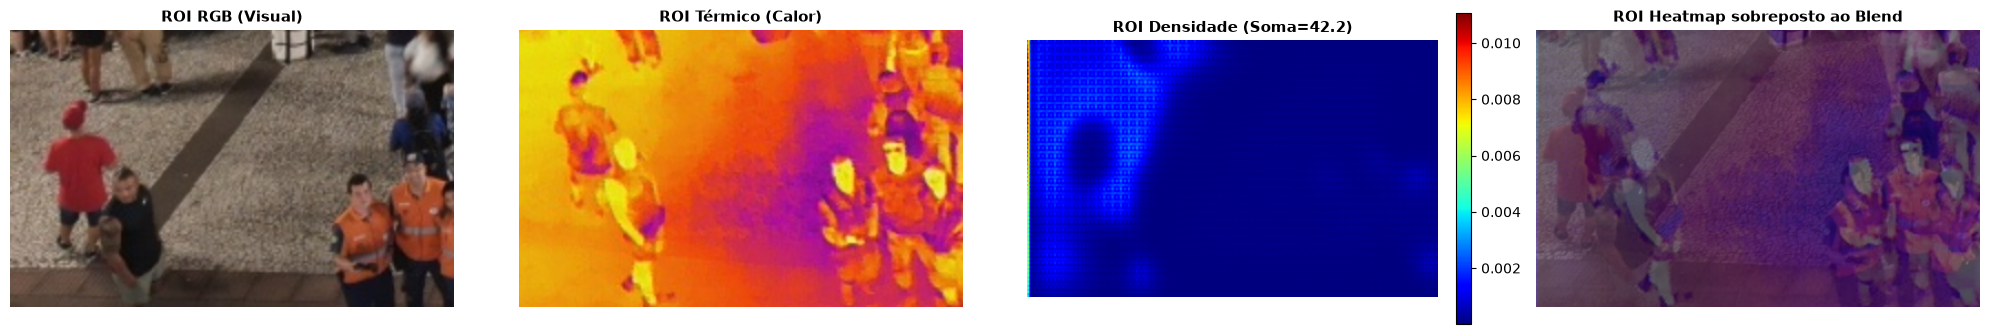

In [11]:
# Definir limites de ROI no canto inferior esquerdo
# Na resolução 1280x1024: y in [750, 1000], x in [0, 400]
y1, y2, x1, x2 = 750, 1000, 0, 400

roi_rgb = cv2.cvtColor(cv2.resize(img_rgb, (1280, 1024))[y1:y2, x1:x2], cv2.COLOR_BGR2RGB)
roi_th = cv2.cvtColor(cv2.resize(img_th, (1280, 1024))[y1:y2, x1:x2], cv2.COLOR_BGR2RGB)
roi_density = cv2.resize(density_map, (1280, 1024))[y1:y2, x1:x2]
roi_blend_overlay = cv2.cvtColor(overlay_blend[y1:y2, x1:x2], cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(roi_rgb)
axes[0].set_title('ROI RGB (Visual)', fontsize=11, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(roi_th)
axes[1].set_title('ROI Térmico (Calor)', fontsize=11, fontweight='bold')
axes[1].axis('off')

im_rd = axes[2].imshow(roi_density, cmap='jet')
axes[2].set_title(f'ROI Densidade (Soma={roi_density.sum():.1f})', fontsize=11, fontweight='bold')
axes[2].axis('off')
plt.colorbar(im_rd, ax=axes[2], fraction=0.035, pad=0.04)

axes[3].imshow(roi_blend_overlay)
axes[3].set_title('ROI Heatmap sobreposto ao Blend', fontsize=11, fontweight='bold')
axes[3].axis('off')

plt.tight_layout()
roi_path = OUTPUT_DIR / 'zoom_roi_pedestres_densidade.jpg'
plt.savefig(str(roi_path), dpi=150, bbox_inches='tight')
plt.show()

print(f'[*] Auditoria de ROI salva em: {roi_path}')


## 6. Exportação de Artefatos e Telemetria

Gravamos os resultados em formato estruturado (JSON de telemetria, mapa de densidade em formato binário NumPy `.npy` e imagem renderizada final) na pasta `notebooks/output/05_contagem/`.


In [13]:
import json

# Gravar mapa de densidade em formato binário para processamentos futuros
npy_path = OUTPUT_DIR / 'density_map.npy'
np.save(str(npy_path), density_map)

# Gravar imagem anotada final
annotated_path = OUTPUT_DIR / 'contagem_final_anotada.jpg'
cv2.imwrite(str(annotated_path), overlay_blend)

# Gravar relatório de telemetria em JSON
summary = {
    'projeto': 'contagem-de-pessoas-rgbt',
    'modelo': 'DualStreamRGBTNet (Density Map Regression)',
    'dispositivo': str(device),
    'entradas': {
        'rgb': str(RGB_IMAGE),
        'thermal': str(THERMAL_IMAGE),
        'blend': str(BLEND_IMAGE)
    },
    'contagem_pessoas_estimada': int(total_people),
    'soma_integral_densidade': float(round(float(density_map.sum()), 2)),
    'tempo_inferencia_ms': round(elapsed_ms, 2),
    'artefatos_gerados': {
        'painel_comparativo': str(panel_path),
        'zoom_roi_pedestres': str(roi_path),
        'imagem_anotada': str(annotated_path),
        'density_map_npy': str(npy_path)
    }
}

json_path = OUTPUT_DIR / 'telemetria_contagem.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print('=' * 55)
print('         ARTEFATOS EXPORTADOS COM SUCESSO')
print('=' * 55)
print(f'1. Telemetria JSON:   {json_path}')
print(f'2. Imagem Anotada:    {annotated_path}')
print(f'3. Matriz Densidade:  {npy_path}')
print(f'4. Painel 2x2:        {panel_path}')
print('=' * 55)


         ARTEFATOS EXPORTADOS COM SUCESSO
1. Telemetria JSON:   /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/output/05_contagem/telemetria_contagem.json
2. Imagem Anotada:    /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/output/05_contagem/contagem_final_anotada.jpg
3. Matriz Densidade:  /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/output/05_contagem/density_map.npy
4. Painel 2x2:        /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/output/05_contagem/painel_contagem_multimodal.jpg
